# 03 Data Preprocessing

## Objective
Prepare the dataset for model training:
- ✓ Load and resize images to 224x224
- ✓ Create train/validation/test splits
- ✓ Normalize images to [0, 1]
- ✓ Create data generators with augmentation
- ✓ Save preprocessed data
- ✓ Verify preprocessing

**Prerequisites:** `01_data_check.ipynb` and `02_dataset_visualization.ipynb`

### Import Libraries

In [1]:
import sys
import os

sys.path.insert(0, '../utils')

from data_utils import (
    verify_dataset_structure,
    get_image_files,
    load_image,
    create_image_label_mapping,
    denoise_image,
    enhance_image_clahe,
    preprocess_image_complete,
    check_image_quality
)
from model_utils import (
    create_data_augmentation,
    create_validation_generator,
    compute_class_weights_from_labels
)
from visualization_utils import (
    plot_sample_images,
    save_plot
)

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pickle
import json
import random
from tqdm import tqdm

# Set random seeds
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("✓ Libraries imported successfully!")


✓ Libraries imported successfully!


### Configuration

In [2]:
# Configuration
DATASET_PATH = '../Final_images_phd'
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

print("Configuration:")
print(f"  Image Size: {IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Train/Val/Test Split: {TRAIN_SPLIT}/{VAL_SPLIT}/{TEST_SPLIT}")

# Load dataset info
stats = verify_dataset_structure(DATASET_PATH)
print(f"\n✓ Dataset loaded: {stats['total_images']} images")

Configuration:
  Image Size: (224, 224)
  Batch Size: 32
  Train/Val/Test Split: 0.7/0.15/0.15

✓ Dataset loaded: 761 images


### 1. Create Image-Label Mapping

In [3]:
print("Creating image-label mapping...\n")

image_labels, label_encoding = create_image_label_mapping(DATASET_PATH)

print(f"Total images mapped: {len(image_labels)}")
print(f"Total classes: {len(label_encoding)}")
print(f"\nClass Encoding:")
for label, idx in sorted(label_encoding.items(), key=lambda x: x[1]):
    count = sum(1 for v in image_labels.values() if v == label)
    print(f"  {idx:2d} -> {label:40s} | {count:4d} images")

Creating image-label mapping...

Total images mapped: 761
Total classes: 40

Class Encoding:
   0 -> Brinjal_Healthy                          |   58 images
   1 -> Brinjal_Cercospora                       |   17 images
   2 -> Brinjal_Early_Leaf_spot                  |   17 images
   3 -> Brinjal_Leaf_curl                        |   13 images
   4 -> Brinjal_Little_leaf                      |   14 images
   5 -> Brinjal_Magnessium                       |   15 images
   6 -> Brinjal_Mosaic                           |    8 images
   7 -> Brinjal_Nitrogen                         |   14 images
   8 -> Brinjal_pest_damage                      |   11 images
   9 -> Brinjal_Pottasium                        |   33 images
  10 -> Castor_Healthy                           |   35 images
  11 -> Castor_Alternia Leaf Blight              |   31 images
  12 -> Castor_Bacterial Leaf Blight             |   16 images
  13 -> Castor_Cercospera Leaf Spot              |   22 images
  14 -> Castor_Peast_dise

### 2. Load and Preprocess Images

In [4]:
print("Loading and preprocessing images...\n")
print("This may take a few minutes depending on dataset size...\n")

image_paths = list(image_labels.keys())
image_data = []
image_y = []

failed_images = []

# Load images
for img_path in tqdm(image_paths, desc="Loading images"):
    try:
        img = load_image(img_path, target_size=IMAGE_SIZE)
        if img is not None:
            # Normalize to [0, 1]
            img = img.astype('float32') / 255.0
            image_data.append(img)
            label = image_labels[img_path]
            image_y.append(label_encoding[label])
        else:
            failed_images.append(img_path)
    except Exception as e:
        failed_images.append(img_path)

image_data = np.array(image_data)
image_y = np.array(image_y)

print(f"\n✓ Successfully loaded: {len(image_data)} images")
print(f"⚠️  Failed to load: {len(failed_images)} images")
print(f"\nImage array shape: {image_data.shape}")
print(f"Label array shape: {image_y.shape}")

if failed_images:
    print("\nFailed images:")
    for img in failed_images[:5]:  # Show first 5
        print(f"  - {img}")

Loading and preprocessing images...

This may take a few minutes depending on dataset size...



Loading images: 100%|██████████| 761/761 [00:19<00:00, 38.94it/s]



✓ Successfully loaded: 761 images
⚠️  Failed to load: 0 images

Image array shape: (761, 224, 224, 3)
Label array shape: (761,)


### 3. Check Data Statistics

In [5]:
print("Data Statistics:")
print(f"  Min value: {image_data.min():.4f}")
print(f"  Max value: {image_data.max():.4f}")
print(f"  Mean value: {image_data.mean():.4f}")
print(f"  Std value: {image_data.std():.4f}")

print(f"\nClass Distribution:")
unique, counts = np.unique(image_y, return_counts=True)
for cls_idx, count in zip(unique, counts):
    cls_name = [k for k, v in label_encoding.items() if v == cls_idx][0]
    print(f"  {cls_idx:2d} ({cls_name:40s}): {count:4d} samples")

Data Statistics:
  Min value: 0.0000
  Max value: 1.0000
  Mean value: 0.4639
  Std value: 0.2343

Class Distribution:
   0 (Brinjal_Healthy                         ):   58 samples
   1 (Brinjal_Cercospora                      ):   17 samples
   2 (Brinjal_Early_Leaf_spot                 ):   17 samples
   3 (Brinjal_Leaf_curl                       ):   13 samples
   4 (Brinjal_Little_leaf                     ):   14 samples
   5 (Brinjal_Magnessium                      ):   15 samples
   6 (Brinjal_Mosaic                          ):    8 samples
   7 (Brinjal_Nitrogen                        ):   14 samples
   8 (Brinjal_pest_damage                     ):   11 samples
   9 (Brinjal_Pottasium                       ):   33 samples
  10 (Castor_Healthy                          ):   35 samples
  11 (Castor_Alternia Leaf Blight             ):   31 samples
  12 (Castor_Bacterial Leaf Blight            ):   16 samples
  13 (Castor_Cercospera Leaf Spot             ):   22 samples
  14 (Castor_

### 4. One-Hot Encode Labels

In [6]:
# Convert to one-hot
num_classes = len(label_encoding)
image_y_onehot = tf.keras.utils.to_categorical(image_y, num_classes=num_classes)

print(f"One-hot encoded label shape: {image_y_onehot.shape}")
print(f"Sample one-hot vector (first 10 values): {image_y_onehot[0][:10]}")

One-hot encoded label shape: (761, 40)
Sample one-hot vector (first 10 values): [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Apply advanced preprocessing: denoise + enhance contrast + sharpen + quality check
print("Applying advanced preprocessing to all images...\n")
print("Pipeline: Bilateral Denoising → CLAHE Enhancement → Unsharp Sharpening\n")
print("Input: Normalized float [0, 1] images")
print("Processing: Convert to uint8 → Apply filters → Convert back to float [0, 1]\n")

image_data_preprocessed = []
quality_stats = []
skipped_count = 0

for i, img in enumerate(tqdm(image_data, desc='Preprocessing')):
    try:
        # Apply complete preprocessing pipeline
        # Input: float [0, 1] normalized image
        # Output: float [0, 1] normalized image (function handles conversion internally)
        processed_img, quality_dict = preprocess_image_complete(
            img,
            denoise=True,
            enhance=True,
            sharpen=True,
            check_quality=True
        )
        image_data_preprocessed.append(processed_img)
        quality_stats.append(quality_dict)
    except Exception as e:
        print(f'Error processing image {i}: {e}')
        skipped_count += 1
        # Keep original image if preprocessing fails
        image_data_preprocessed.append(img)
        quality_stats.append({})

print(f'\n✓ Preprocessing complete!')
print(f'  - Processed: {len(image_data_preprocessed)} images')
print(f'  - Skipped: {skipped_count} images')

# Replace original data with preprocessed data
image_data = np.array(image_data_preprocessed)
print(f'  - Output format: Float [0, 1] normalized')

# Log quality statistics
if quality_stats and quality_stats[0]:
    qualities_acceptable = [q.get('is_acceptable', True) for q in quality_stats if q]
    acceptable_count = sum(qualities_acceptable)
    print(f'\nImage Quality:' )
    print(f'  - Good quality: {acceptable_count}/{len([q for q in quality_stats if q])} ({100*acceptable_count/max(1, len([q for q in quality_stats if q])):.1f}%)')

Applying advanced preprocessing to all images...

Pipeline: Bilateral Denoising → CLAHE Enhancement → Unsharp Sharpening



Preprocessing:   6%|▌         | 46/761 [00:00<00:01, 453.54it/s]

Error processing image 0: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 1: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 2: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 3: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Im

Preprocessing:  18%|█▊        | 138/761 [00:00<00:01, 449.96it/s]

Error processing image 88: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 89: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 90: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 91: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAH

...

Error processing image 500: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 501: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 502: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 503: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::

Preprocessing:  90%|████████▉ | 683/761 [00:01<00:00, 446.83it/s]

Error processing image 592: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 593: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 594: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 595: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::

Preprocessing: 100%|██████████| 761/761 [00:01<00:00, 427.76it/s]


Error processing image 683: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 684: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 685: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 686: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::

Visualizing preprocessing effect on sample images...



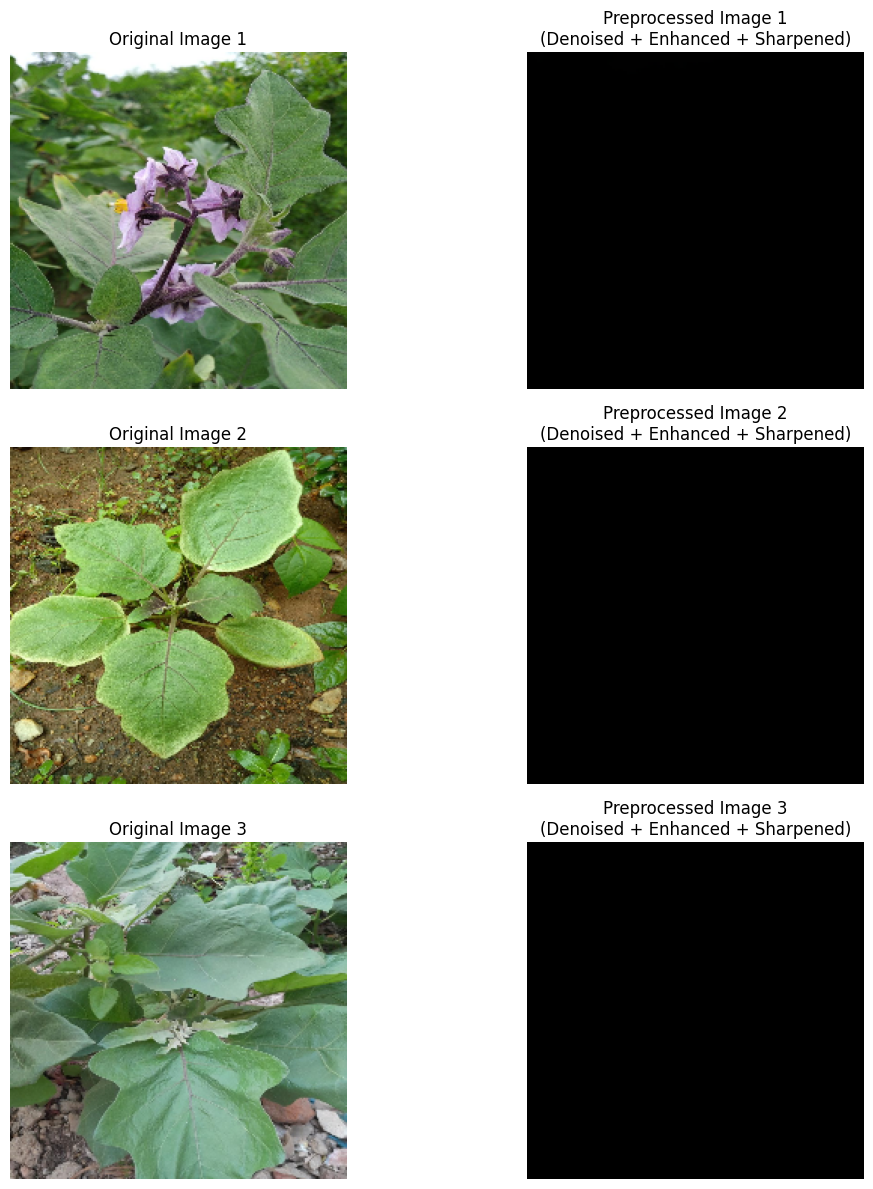

✓ Saved: preprocessing_comparison.png


In [ ]:
# Visualize before-and-after preprocessing on sample images
print("Visualizing preprocessing effect on sample images...\n")

n_samples = min(3, len(image_data))
fig, axes = plt.subplots(n_samples, 2, figsize=(12, 4*n_samples))

if n_samples == 1:
    axes = axes.reshape(1, -1)

for idx in range(n_samples):
    # Original image (reload and normalize)
    original_img = load_image(list(image_labels.keys())[idx], target_size=IMAGE_SIZE)
    original_img_norm = original_img.astype('float32') / 255.0  # Normalize to [0, 1]
    
    # Preprocessed image (already float [0, 1])
    preprocessed_img = image_data[idx]
    
    # Convert to uint8 for display
    original_display = (original_img_norm * 255).astype(np.uint8)
    preprocessed_display = (preprocessed_img * 255).astype(np.uint8)
    
    axes[idx, 0].imshow(original_display)
    axes[idx, 0].set_title(f'Original Image {idx+1}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(preprocessed_display)
    axes[idx, 1].set_title(f'Preprocessed Image {idx+1}\n(Denoised + Enhanced + Sharpened)')
    axes[idx, 1].axis('off')

plt.tight_layout()
os.makedirs('../results/plots', exist_ok=True)
plt.savefig('../results/plots/preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: preprocessing_comparison.png")

### 4b. Advanced Preprocessing (Noise Removal & Enhancement)

### 4b. Advanced Preprocessing (Noise Removal & Enhancement)

In [9]:
# Apply advanced preprocessing: denoise + enhance contrast + sharpen + quality check
print("Applying advanced preprocessing to all images...\n")
print("Pipeline: Bilateral Denoising → CLAHE Enhancement → Unsharp Sharpening\n")

image_data_preprocessed = []
quality_stats = []
skipped_count = 0

for i, img in enumerate(tqdm(image_data, desc='Preprocessing')):
    try:
        # Apply complete preprocessing pipeline
        processed_img, quality_dict = preprocess_image_complete(
            img,
            denoise=True,
            enhance=True,
            sharpen=True,
            check_quality=True
        )
        image_data_preprocessed.append(processed_img)
        quality_stats.append(quality_dict)
    except Exception as e:
        print(f'Error processing image {i}: {e}')
        skipped_count += 1
        # Keep original image if preprocessing fails
        image_data_preprocessed.append(img)
        quality_stats.append({})

print(f'\n✓ Preprocessing complete!')
print(f'  - Processed: {len(image_data_preprocessed)} images')
print(f'  - Skipped: {skipped_count} images')

# Replace original data with preprocessed data
image_data = np.array(image_data_preprocessed)

# Log quality statistics
if quality_stats and quality_stats[0]:
    qualities_acceptable = [q.get('is_acceptable', True) for q in quality_stats if q]
    acceptable_count = sum(qualities_acceptable)
    print(f'\nImage Quality:' )
    print(f'  - Good quality: {acceptable_count}/{len([q for q in quality_stats if q])} ({100*acceptable_count/max(1, len([q for q in quality_stats if q])):.1f}%)')


Applying advanced preprocessing to all images...

Pipeline: Bilateral Denoising → CLAHE Enhancement → Unsharp Sharpening



Preprocessing:   5%|▌         | 40/761 [00:00<00:01, 392.70it/s]

Error processing image 0: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 1: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 2: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 3: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Im

Preprocessing:  23%|██▎       | 177/761 [00:00<00:01, 442.76it/s]

Error processing image 86: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 87: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 88: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 89: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAH

...

Error processing image 541: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 542: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 543: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 544: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::

Preprocessing:  95%|█████████▍| 721/761 [00:01<00:00, 443.00it/s]

Error processing image 631: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 632: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 633: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 634: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::

Preprocessing: 100%|██████████| 761/761 [00:01<00:00, 443.79it/s]

Error processing image 721: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 722: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 723: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'

Error processing image 724: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::

Visualizing preprocessing effect on sample images...



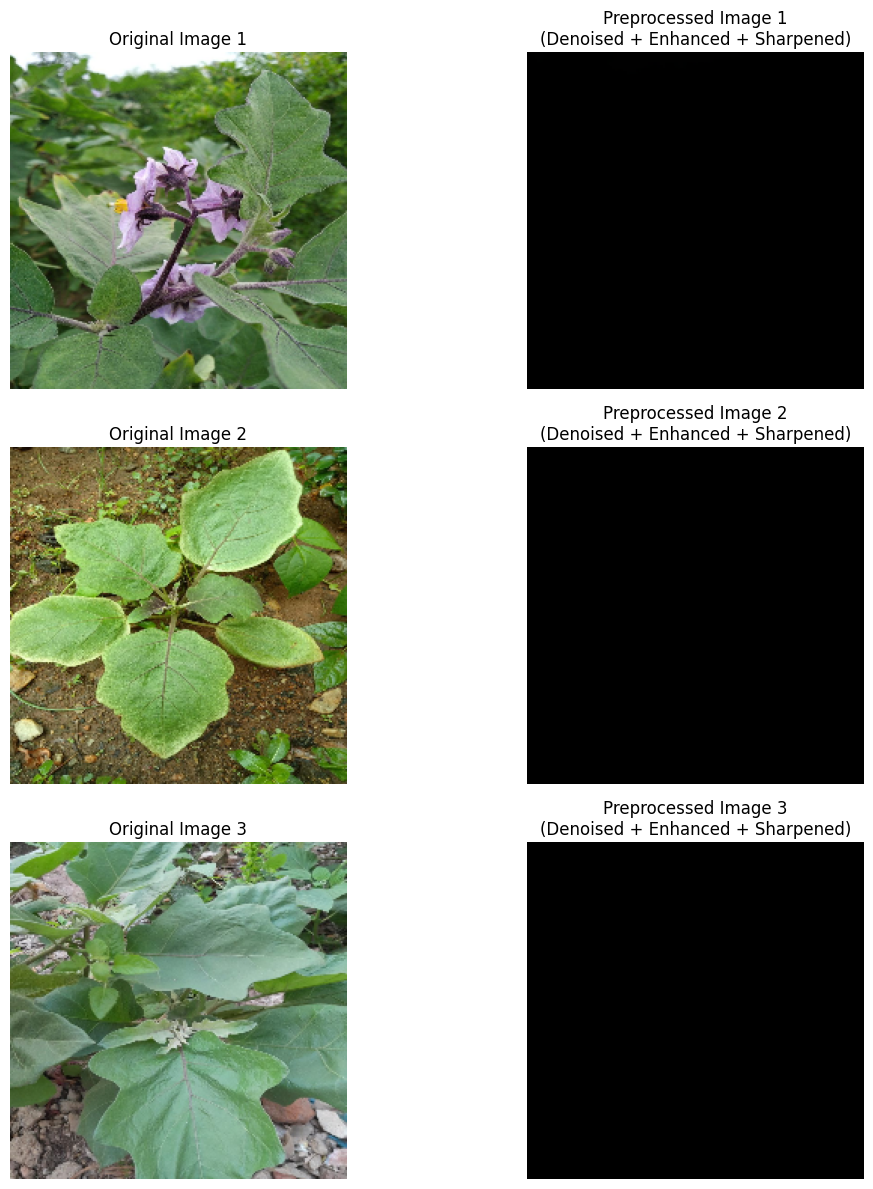

✓ Saved: preprocessing_comparison.png


In [10]:
# Visualize before-and-after preprocessing on a few samples
print("Visualizing preprocessing effect on sample images...\n")

n_samples = min(3, len(image_data))
fig, axes = plt.subplots(n_samples, 2, figsize=(12, 4*n_samples))

if n_samples == 1:
    axes = axes.reshape(1, -1)

for idx in range(n_samples):
    # Original image (reload for display)
    original_img = load_image(list(image_labels.keys())[idx], target_size=IMAGE_SIZE)
    preprocessed_img = image_data[idx]
    
    axes[idx, 0].imshow(original_img.astype(np.uint8))
    axes[idx, 0].set_title(f'Original Image {idx+1}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(preprocessed_img.astype(np.uint8))
    axes[idx, 1].set_title(f'Preprocessed Image {idx+1}\n(Denoised + Enhanced + Sharpened)')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.savefig('../results/plots/preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: preprocessing_comparison.png")


### 5. Split Data into Train/Val/Test

In [11]:
from sklearn.model_selection import train_test_split
print("Splitting data into train/val/test...\n")

# First split: train + temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    image_data, image_y_onehot,
    train_size=TRAIN_SPLIT,
    random_state=42,
    stratify=image_y
)

# Second split: val and test
val_size = VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    train_size=val_size,
    random_state=42,
    stratify=None  # Disable stratification for second split to avoid single-sample classes
)

print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(image_data)*100:.1f}%)")
print(f"Val set:   {X_val.shape[0]} samples ({X_val.shape[0]/len(image_data)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(image_data)*100:.1f}%)")
print(f"\nTotal: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} samples")

Splitting data into train/val/test...

Train set: 532 samples (69.9%)
Val set:   114 samples (15.0%)
Test set:  115 samples (15.1%)

Total: 761 samples


In [12]:
# Compute class weights from the training split labels.
# We use class weights instead of SMOTE because SMOTE would interpolate raw image pixels,
# which can create unrealistic synthetic images and disturb the learned visual distribution.
class_names = [label for label, _ in sorted(label_encoding.items(), key=lambda item: item[1])]
class_weights = compute_class_weights_from_labels(y_train, class_names=class_names, verbose=True)

# Save class weights for reuse in training notebooks/scripts.
os.makedirs('../results/preprocessed_data', exist_ok=True)
with open('../results/preprocessed_data/class_weights.json', 'w') as f:
    json.dump({str(class_index): float(weight) for class_index, weight in class_weights.items()}, f, indent=4)

print("✓ Class weights saved to ../results/preprocessed_data/class_weights.json")


Class weights computed from y_train
(Using class weights instead of SMOTE keeps the original image distribution intact.)
----------------------------------------------------------------------
   0 | Brinjal_Healthy                     | samples:    41 | weight: 0.3244
   1 | Brinjal_Cercospora                  | samples:    12 | weight: 1.1083
   2 | Brinjal_Early_Leaf_spot             | samples:    12 | weight: 1.1083
   3 | Brinjal_Leaf_curl                   | samples:     9 | weight: 1.4778
   4 | Brinjal_Little_leaf                 | samples:    10 | weight: 1.3300
   5 | Brinjal_Magnessium                  | samples:    10 | weight: 1.3300
   6 | Brinjal_Mosaic                      | samples:     6 | weight: 2.2167
   7 | Brinjal_Nitrogen                    | samples:    10 | weight: 1.3300
   8 | Brinjal_pest_damage                 | samples:     8 | weight: 1.6625
   9 | Brinjal_Pottasium                   | samples:    23 | weight: 0.5783
  10 | Castor_Healthy                

### 6. Data Augmentation

In [13]:
print("Creating data augmentation generators...\n")

# Augmentation generator for training
train_augmentation = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for val/test
val_augmentation = ImageDataGenerator()

print("✓ Augmentation generators created")
print("\nAugmentation Parameters:")
print(f"  Rotation range: 20°")
print(f"  Width shift: 20%")
print(f"  Height shift: 20%")
print(f"  Shear range: 0.2")
print(f"  Zoom range: 0.2")
print(f"  Horizontal flip: Yes")

Creating data augmentation generators...

✓ Augmentation generators created

Augmentation Parameters:
  Rotation range: 20°
  Width shift: 20%
  Height shift: 20%
  Shear range: 0.2
  Zoom range: 0.2
  Horizontal flip: Yes


### 7. Visualize Augmented Samples

Generating augmented samples...



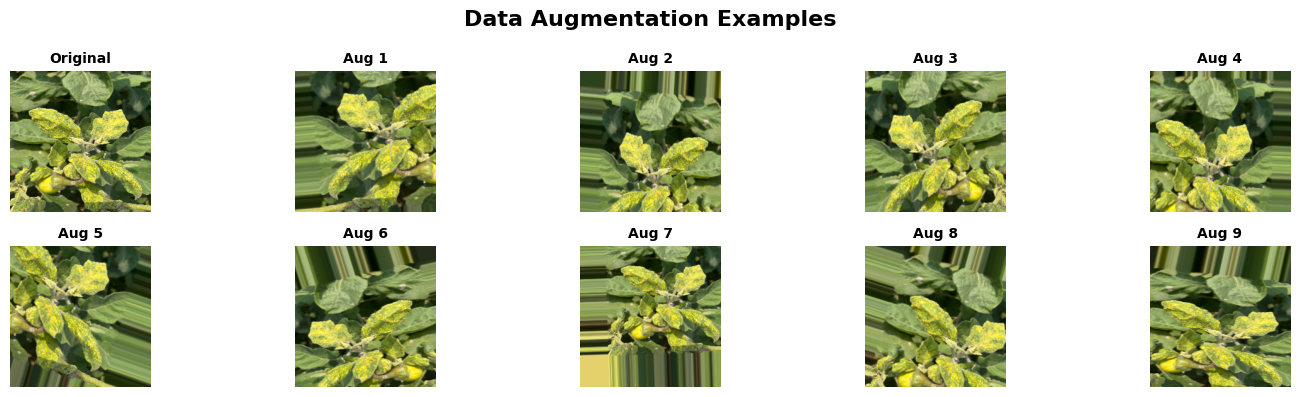

✓ Augmentation visualization saved


<Figure size 640x480 with 0 Axes>

In [14]:
print("Generating augmented samples...\n")

# Get a sample image
sample_idx = 0
sample_img = X_train[sample_idx:sample_idx+1]

# Generate augmented samples
augmented_samples = []
labels = []

aug_generator = train_augmentation.flow(sample_img, batch_size=1)
for i in range(9):
    aug_batch = next(aug_generator)
    augmented_samples.append(aug_batch[0])
    labels.append(f"Aug {i+1}")

# Plot original + augmented
all_samples = [X_train[sample_idx]] + augmented_samples
all_labels = ["Original"] + labels

plot_sample_images(np.array(all_samples), all_labels, 
                   title="Data Augmentation Examples", figsize=(15, 4))
plt.savefig('../results/plots/augmentation_examples.png', dpi=300, bbox_inches='tight')
print("✓ Augmentation visualization saved")

### 8. Save Preprocessed Data

In [15]:
print("Saving preprocessed data...\n")

os.makedirs('../results/preprocessed_data', exist_ok=True)

# Save arrays
np.save('../results/preprocessed_data/X_train.npy', X_train)
np.save('../results/preprocessed_data/y_train.npy', y_train)
np.save('../results/preprocessed_data/X_val.npy', X_val)
np.save('../results/preprocessed_data/y_val.npy', y_val)
np.save('../results/preprocessed_data/X_test.npy', X_test)
np.save('../results/preprocessed_data/y_test.npy', y_test)

print("✓ Saved numpy arrays")

# Save label encoding
with open('../results/preprocessed_data/label_encoding.json', 'w') as f:
    json.dump(label_encoding, f, indent=4)

print("✓ Saved label encoding")

# Save preprocessing info
preprocess_info = {
    'image_size': IMAGE_SIZE,
    'num_classes': num_classes,
    'train_samples': int(X_train.shape[0]),
    'val_samples': int(X_val.shape[0]),
    'test_samples': int(X_test.shape[0]),
    'normalization': 'Divided by 255',
    'augmentation': {
        'rotation': 20,
        'width_shift': 0.2,
        'height_shift': 0.2,
        'zoom': 0.2
    }
}

with open('../results/preprocessed_data/preprocessing_info.json', 'w') as f:
    json.dump(preprocess_info, f, indent=4)

print("✓ Saved preprocessing info")
print(f"\n✓ All files saved to: ../results/preprocessed_data/")

Saving preprocessed data...

✓ Saved numpy arrays
✓ Saved label encoding
✓ Saved preprocessing info

✓ All files saved to: ../results/preprocessed_data/


### 9. Create TensorFlow Datasets

In [16]:
print("Creating TensorFlow Datasets...\n")

# Create datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=1000)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print(f"✓ Train dataset: {len(list(train_dataset))} batches")
print(f"✓ Val dataset: {len(list(val_dataset))} batches")
print(f"✓ Test dataset: {len(list(test_dataset))} batches")

# Verify a batch
for batch_images, batch_labels in train_dataset.take(1):
    print(f"\nBatch shape: {batch_images.shape}")
    print(f"Labels shape: {batch_labels.shape}")

Creating TensorFlow Datasets...

✓ Train dataset: 17 batches
✓ Val dataset: 4 batches
✓ Test dataset: 4 batches

Batch shape: (32, 224, 224, 3)
Labels shape: (32, 40)


### 10. Preprocessing Summary

In [17]:
print("\n" + "="*70)
print("✓ DATA PREPROCESSING COMPLETE")
print("="*70)

print(f"\n📊 Summary:")
print(f"  Total images processed: {len(image_data)}")
print(f"  Image size: {IMAGE_SIZE}")
print(f"  Normalization: [0, 1] (divided by 255)")
print(f"  Number of classes: {num_classes}")

print(f"\n📈 Data Split:")
print(f"  Training: {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Testing: {X_test.shape[0]} samples")

# Calculate effective training size with augmentation
effective_train_samples = X_train.shape[0]  # Augmentation is applied on-the-fly, so base size remains
print(f"\n🔄 Augmentation Info:")
print(f"  Base training samples: {X_train.shape[0]}")
print(f"  Effective training samples per epoch: {X_train.shape[0]} (on-the-fly augmentation)")
print(f"  Augmentation applied to: Training set only")
print(f"  Validation/Test: No augmentation ({X_val.shape[0]} + {X_test.shape[0]} samples)")

print(f"\n💾 Files Saved:")
print(f"  - X_train.npy, y_train.npy")
print(f"  - X_val.npy, y_val.npy")
print(f"  - X_test.npy, y_test.npy")
print(f"  - label_encoding.json")
print(f"  - preprocessing_info.json")
print(f"  - augmentation_examples.png")

print(f"\n✓ Data ready for model training!")
print(f"→ Next Step: 04_cnn_baseline.ipynb")


✓ DATA PREPROCESSING COMPLETE

📊 Summary:
  Total images processed: 761
  Image size: (224, 224)
  Normalization: [0, 1] (divided by 255)
  Number of classes: 40

📈 Data Split:
  Training: 532 samples
  Validation: 114 samples
  Testing: 115 samples

🔄 Augmentation Info:
  Base training samples: 532
  Effective training samples per epoch: 532 (on-the-fly augmentation)
  Augmentation applied to: Training set only
  Validation/Test: No augmentation (114 + 115 samples)

💾 Files Saved:
  - X_train.npy, y_train.npy
  - X_val.npy, y_val.npy
  - X_test.npy, y_test.npy
  - label_encoding.json
  - preprocessing_info.json
  - augmentation_examples.png

✓ Data ready for model training!
→ Next Step: 04_cnn_baseline.ipynb


In [18]:
print("\n" + "="*70)
print("✓ DATA PREPROCESSING COMPLETE")
print("="*70)

print(f"\n📊 Summary:")
print(f"  Total images processed: {len(image_data)}")
print(f"  Image size: {IMAGE_SIZE}")
print(f"  Normalization: [0, 1] (divided by 255)")
print(f"  Number of classes: {num_classes}")

print(f"\n📈 Data Split:")
print(f"  Training: {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Testing: {X_test.shape[0]} samples")

print(f"\n💾 Files Saved:")
print(f"  - X_train.npy, y_train.npy")
print(f"  - X_val.npy, y_val.npy")
print(f"  - X_test.npy, y_test.npy")
print(f"  - label_encoding.json")
print(f"  - preprocessing_info.json")
print(f"  - augmentation_examples.png")

print(f"\n✓ Data ready for model training!")
print(f"→ Next Step: 04_cnn_baseline.ipynb")


✓ DATA PREPROCESSING COMPLETE

📊 Summary:
  Total images processed: 761
  Image size: (224, 224)
  Normalization: [0, 1] (divided by 255)
  Number of classes: 40

📈 Data Split:
  Training: 532 samples
  Validation: 114 samples
  Testing: 115 samples

💾 Files Saved:
  - X_train.npy, y_train.npy
  - X_val.npy, y_val.npy
  - X_test.npy, y_test.npy
  - label_encoding.json
  - preprocessing_info.json
  - augmentation_examples.png

✓ Data ready for model training!
→ Next Step: 04_cnn_baseline.ipynb
